# INTRODUCCIÓN A LA CIENCIA DE DATOS ESPACIALES - EVALUACIÓN GRUPAL


### **Grupo Temático:** Chile

---

### **Integrantes:**
* **Diego Eduardo Monja Zagaceta** — 20242642
* **Alessandra Isabel Mendoza Tordoya** — 20245523
* **Jorge Daniel Quiroz Huamán** — 20267609

---

## 1. Carga y revisión de los datos:

**Importación de librerías y lectura de datos**

En este apartado se importan las librerías necesarias para trabajar con información espacial y datos tabulares. Se utiliza ***GeoPandas*** para trabajar con los datos geográficos y ***Pandas*** para manejar la información de población.

In [ ]:
#Importamos las librerias necesarias
import geopandas as gpd
import pandas as pd

#Leemos los datos desde Github
linkGit = 'https://github.com/DiegoMonja/ICDE_EVALUACION_GRUPAL_1/raw/main/'
linkMapa = linkGit + 'gadm41_CHL_1.json'
linkPoblacion = linkGit + 'Datos_poblacion.csv'

#Leemos los datos en una variable
chile = gpd.read_file(linkMapa)
poblacion = pd.read_csv(linkPoblacion)

In [ ]:
#Revisamos el nombre de las columnas y de las regiones
chile

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,CHL.2_1,CHL,Chile,Antofagasta,NA,NA,Región,Region,II,CL.AN,CL-AN,"MULTIPOLYGON (((-70.7398 -25.8266, -70.7397 -2..."
1,CHL.3_1,CHL,Chile,Araucanía,Araucanie|LaAraucanía,NA,Región,Region,IX,CL.AR,NA,"MULTIPOLYGON (((-71.4354 -38.9865, -71.4273 -3..."
2,CHL.4_1,CHL,Chile,AricayParinacota,NA,NA,Región,Region,XV,CL.AP,CL-AP,"MULTIPOLYGON (((-69.2819 -17.9685, -69.276 -17..."
3,CHL.5_1,CHL,Chile,Atacama,NA,NA,Región,Region,III,CL.AT,CL-AT,"MULTIPOLYGON (((-71.2611 -28.4928, -71.2612 -2..."
4,CHL.1_1,CHL,Chile,AyséndelGeneralIbañezdelCam,Aisén|Aysén|AiséndelGeneralCa,NA,Región,Region,XI,CL.AI,NA,"MULTIPOLYGON (((-74.19086 -46.75097, -74.181 -..."
5,CHL.6_1,CHL,Chile,Bío-Bío,Bíobío,NA,Región,Region,VIII,CL.BI,NA,"MULTIPOLYGON (((-73.9479 -38.3174, -73.9335 -3..."
6,CHL.7_1,CHL,Chile,Coquimbo,NA,NA,Región,Region,IV,CL.CO,CL-CO,"MULTIPOLYGON (((-71.5328 -29.5822, -71.5364 -2..."
7,CHL.8_1,CHL,Chile,LibertadorGeneralBernardoO'Hi,Libertador,NA,Región,Region,VI,CL.LI,NA,"MULTIPOLYGON (((-71.5483 -34.8744, -71.5529 -3..."
8,CHL.9_1,CHL,Chile,LosLagos,OsLagos,NA,Región,Region,X,CL.LL,CL-LL,"MULTIPOLYGON (((-74.848 -43.5998, -74.849 -43...."
9,CHL.10_1,CHL,Chile,LosRíos,NA,NA,Región,Region,XIV,CL.LR,NA,"MULTIPOLYGON (((-73.3056 -39.9527, -73.3071 -3..."


In [ ]:
#Revisamos el nombre de las columnas y de las regiones
poblacion

,Unidad territorial,Variable,2024
0,Región De Arica Y Parinacota,Población total,244569.0
1,Región De Tarapacá,Población total,369806.0
2,Región De Antofagasta,Población total,635416.0
3,Región De Atacama,Población total,299180.0
4,Región De Coquimbo,Población total,832864.0
5,Región De Valparaíso,Población total,1896053.0
6,Región Metropolitana De Santiago,Población total,7400741.0
7,Región Del Libertador Gral. Bernardo O'higgins,Población total,987228.0
8,Región Del Maule,Población total,1123008.0
9,Región de Ñuble,Población total,512289.0


## 2. Preparación de los datos para el Geo Merge

**Normalización de la clave**

Primero se cambia el nombre de las columnas que identifican la región en cada conjunto de datos. De esta manera, tanto la información espacial como la información de población utilizan **Region** como clave común para realizar posteriormente la unión de los datos.

In [ ]:
#Homonizamos el nombre de las columnas
chile.rename(columns={'NAME_1':'Region'}, inplace=True)
poblacion.rename(columns={'Unidad territorial':'Region'}, inplace=True)

**Comparación de los nombres**

Después de normalizar los datos, se comprueba si existen nombres que aparecen únicamente en una de las dos fuentes. Esta comparación permite detectar diferencias de escritura que podrían impedir que el Geo Merge se realice correctamente.

In [ ]:
#Verificamos que regiones de Chile no son reconocidas por el sistema
onlyDF = set(poblacion.Region) - set(chile.Region)
onlyGDF = set(chile.Region) - set(poblacion.Region)
print("Solo en someData:", onlyDF)
print("Solo en countries:", onlyGDF)

Solo en someData: {'Región De La Araucanía', 'Región De Los Ríos', 'Región De Tarapacá', 'Región De Arica Y Parinacota', 'Región De Valparaíso', 'Región De Antofagasta', 'Región De Los Lagos', 'Región De Magallanes Y De La Antártica Chilena', 'Región Del Maule', 'Región de Ñuble', 'Región Del Biobío', 'Región Metropolitana De Santiago', 'Región De Atacama', 'Región De Aysén Del Gral. Carlos Ibáñez Del Campo', "Región Del Libertador Gral. Bernardo O'higgins", 'Región De Coquimbo'}
Solo en countries: {'MagallanesyAntárticaChilena', 'Bío-Bío', "LibertadorGeneralBernardoO'Hi", 'AyséndelGeneralIbañezdelCam', 'Atacama', 'Araucanía', 'Maule', 'SantiagoMetropolitan', 'Tarapacá', 'Ñuble', 'Valparaíso', 'LosRíos', 'LosLagos', 'Coquimbo', 'Antofagasta', 'AricayParinacota'}


## 3. Corrección de los nombres

Cuando se encuentran diferencias entre los nombres de ambas fuentes, se utiliza thefuzz para buscar coincidencias aproximadas. De esta manera, se pueden identificar nombres que probablemente hacen referencia a la misma división administrativa, pero que presentan diferencias en su escritura.

In [ ]:
#Para encontrar las coincidencias en las regiones, se usará la libreria thefuzz
!pip install thefuzz
#Se define la función para comparar los nombres
from thefuzz.process import extractOne as best
#Se muestran las coincidencias y su nivel de similitud
pd.DataFrame([(Region, best(Region,onlyGDF)[0],best(Region,onlyGDF)[1]) for Region in onlyDF]).sort_values(by=2)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.5 MB/s eta 0:00:00


,0,1,2
13,Región De Aysén Del Gral. Carlos Ibáñez Del Campo,AyséndelGeneralIbañezdelCam,60
11,Región Metropolitana De Santiago,SantiagoMetropolitan,62
7,Región De Magallanes Y De La Antártica Chilena,MagallanesyAntárticaChilena,74
1,Región De Los Ríos,LosRíos,75
14,Región Del Libertador Gral. Bernardo O'higgins,LibertadorGeneralBernardoO'Hi,78
6,Región De Los Lagos,LosLagos,79
3,Región De Arica Y Parinacota,AricayParinacota,79
10,Región Del Biobío,Bío-Bío,86
4,Región De Valparaíso,Valparaíso,90
5,Región De Antofagasta,Antofagasta,90


**Corrección de los nombres**

A partir de las coincidencias identificadas, se establece una correspondencia entre los nombres diferentes. Posteriormente, estas equivalencias se aplican sobre la tabla de población para que ambas fuentes utilicen exactamente los mismos identificadores.

In [ ]:
#Creamos el diccionario con las regiones
changesToDF = {Region:best(Region,onlyGDF)[0] for Region in onlyDF}
changesToDF

{'Región De La Araucanía': 'Araucanía',
 'Región De Los Ríos': 'LosRíos',
 'Región De Tarapacá': 'Tarapacá',
 'Región De Arica Y Parinacota': 'AricayParinacota',
 'Región De Valparaíso': 'Valparaíso',
 'Región De Antofagasta': 'Antofagasta',
 'Región De Los Lagos': 'LosLagos',
 'Región De Magallanes Y De La Antártica Chilena': 'MagallanesyAntárticaChilena',
 'Región Del Maule': 'Maule',
 'Región de Ñuble': 'Ñuble',
 'Región Del Biobío': 'Bío-Bío',
 'Región Metropolitana De Santiago': 'SantiagoMetropolitan',
 'Región De Atacama': 'Atacama',
 'Región De Aysén Del Gral. Carlos Ibáñez Del Campo': 'AyséndelGeneralIbañezdelCam',
 "Región Del Libertador Gral. Bernardo O'higgins": "LibertadorGeneralBernardoO'Hi",
 'Región De Coquimbo': 'Coquimbo'}

In [ ]:
#Al ver que las coincidencias son correctas realizamos el reemplazo
poblacion.replace(to_replace={'Region' :changesToDF},inplace=True)

**Verificación de la corrección**

Finalmente, se vuelve a realizar la comparación de los nombres. Esta comprobación permite verificar si las diferencias fueron corregidas antes de realizar la unión de los datos.

In [ ]:
#Verificamos si aún quedan regiones
onlyDF = set(poblacion.Region) - set(chile.Region)
onlyGDF = set(chile.Region) - set(poblacion.Region)
print("Solo en someData:", len(onlyDF))
print("Solo en countries:", len(onlyGDF))

Solo en someData: 0
Solo en countries: 0


## 4. Integración de la información

**Realización del Merge**

Una vez que los nombres han sido normalizados y corregidos, se realiza el merge entre el GeoDataFrame y la tabla de población. La unión permite incorporar los datos estadísticos a las geometrías correspondientes de Chile.

In [ ]:
#Se une la información espacial con los datos estadísticos
MapaDatosChile = chile.merge(poblacion, on='Region')
MapaDatosChile

,GID_1,GID_0,COUNTRY,Region,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry,Variable,2024
0,CHL.2_1,CHL,Chile,Antofagasta,NA,NA,Región,Region,II,CL.AN,CL-AN,"MULTIPOLYGON (((-70.7398 -25.8266, -70.7397 -2...",Población total,635416.0
1,CHL.3_1,CHL,Chile,Araucanía,Araucanie|LaAraucanía,NA,Región,Region,IX,CL.AR,NA,"MULTIPOLYGON (((-71.4354 -38.9865, -71.4273 -3...",Población total,1010423.0
2,CHL.4_1,CHL,Chile,AricayParinacota,NA,NA,Región,Region,XV,CL.AP,CL-AP,"MULTIPOLYGON (((-69.2819 -17.9685, -69.276 -17...",Población total,244569.0
3,CHL.5_1,CHL,Chile,Atacama,NA,NA,Región,Region,III,CL.AT,CL-AT,"MULTIPOLYGON (((-71.2611 -28.4928, -71.2612 -2...",Población total,299180.0
4,CHL.1_1,CHL,Chile,AyséndelGeneralIbañezdelCam,Aisén|Aysén|AiséndelGeneralCa,NA,Región,Region,XI,CL.AI,NA,"MULTIPOLYGON (((-74.19086 -46.75097, -74.181 -...",Población total,100745.0
5,CHL.6_1,CHL,Chile,Bío-Bío,Bíobío,NA,Región,Region,VIII,CL.BI,NA,"MULTIPOLYGON (((-73.9479 -38.3174, -73.9335 -3...",Población total,1613059.0
6,CHL.7_1,CHL,Chile,Coquimbo,NA,NA,Región,Region,IV,CL.CO,CL-CO,"MULTIPOLYGON (((-71.5328 -29.5822, -71.5364 -2...",Población total,832864.0
7,CHL.8_1,CHL,Chile,LibertadorGeneralBernardoO'Hi,Libertador,NA,Región,Region,VI,CL.LI,NA,"MULTIPOLYGON (((-71.5483 -34.8744, -71.5529 -3...",Población total,987228.0
8,CHL.9_1,CHL,Chile,LosLagos,OsLagos,NA,Región,Region,X,CL.LL,CL-LL,"MULTIPOLYGON (((-74.848 -43.5998, -74.849 -43....",Población total,890284.0
9,CHL.10_1,CHL,Chile,LosRíos,NA,NA,Región,Region,XIV,CL.LR,NA,"MULTIPOLYGON (((-73.3056 -39.9527, -73.3071 -3...",Población total,398230.0


In [ ]:
#Verificamos los datos
MapaDatosChile[['Region', ' 2024']]

,Region,2024
0,Antofagasta,635416.0
1,Araucanía,1010423.0
2,AricayParinacota,244569.0
3,Atacama,299180.0
4,AyséndelGeneralIbañezdelCam,100745.0
5,Bío-Bío,1613059.0
6,Coquimbo,832864.0
7,LibertadorGeneralBernardoO'Hi,987228.0
8,LosLagos,890284.0
9,LosRíos,398230.0


Se guarda el GeoDatoFrame en un archivo.

In [ ]:
#Guardamos el mapa con los datos obtenidos
MapaDatosChile.to_file('MapaDatosChile.json')

## 5. Preparación espacial

**Revisión del sistema de coordenadas y la proyección**

En este apartado se revisa el sistema de coordenadas utilizado por MapaDatosChile y se verifica si este se encuentra proyectado mediante is_projected. Esta comprobación permite conocer las características de la proyección antes de realizar las operaciones espaciales posteriores y determinar si es necesario transformar el sistema de coordenadas.

In [ ]:
# Se revisa el sistema de coordenadas
MapaDatosChile.crs
# Se comprueba si el sistema está proyectado
MapaDatosChile.crs.is_projected

False

**Transformación del sistema de coordenadas**

A partir de la revisión anterior, se realiza la transformación al sistema de coordenadas que se utilizará para las operaciones espaciales posteriores. En el ejemplo de trabajo se utiliza el EPSG 5361, por lo que se aplica la misma transformación al mapa de Chile.

<Axes: >

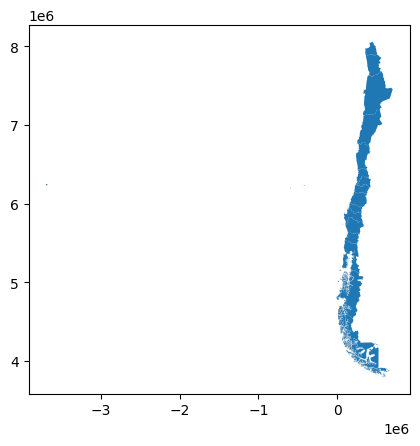

In [ ]:
# Transformamos el mapa al sistema de coordenadas 8857
MapaDatosChile_5361 = MapaDatosChile.to_crs(5361)
# Se comprueba visualmente la proyección
MapaDatosChile_5361.plot()

## 6. DDM (Dot Density Map)

En este apartado se representa la población de las regiones de Chile mediante puntos. Cada punto representa una cantidad determinada de habitantes, permitiendo observar la distribución espacial de la población.



**Preparación de los datos**

Se realiza una copia del GeoDataFrame proyectado y se establece el valor de población que representará cada punto. Posteriormente, se calcula la cantidad de puntos correspondiente a cada región.

In [ ]:
# Creamos una copia de los datos proyectados
Chile_dots = MapaDatosChile_5361.copy()
# Establecemos cuántos habitantes representa cada punto
dot_value = 18000
# Calculamos la cantidad de puntos para cada región
Chile_dots['num_dots'] = (Chile_dots[' 2024'] / dot_value).astype(int)

**Generación de los puntos**

A partir de la cantidad calculada para cada región, se generan los puntos dentro de sus respectivas geometrías. Luego, cada punto se convierte en una observación independiente.

In [ ]:
# Generamos los puntos dentro de cada región
Chile_dots = Chile_dots.sample_points(size=Chile_dots['num_dots']).explode(index_parts=True)
# Reiniciamos el índic
Chile_dots.reset_index(drop=True, inplace=True)
# Creamos el GeoDataFrame de puntos
Chile_dots = gpd.GeoDataFrame( geometry=Chile_dots)
# Se muestran los puntos generados
Chile_dots

,geometry
0,POINT (579227.181 7550918.012)
1,POINT (454987.025 7227688.926)
2,POINT (525361.71 7301710.062)
3,POINT (504155.273 7492294.008)
4,POINT (488262.793 7384904.537)
...,...
1015,POINT (262153.899 6272804.968)
1016,POINT (396055.835 6345828.991)
1017,POINT (326080.552 6429924.561)
1018,POINT (340168.159 6371526.704)


**Representación del mapa**

Finalmente, se representan las regiones como mapa base y los puntos de población sobre ellas.

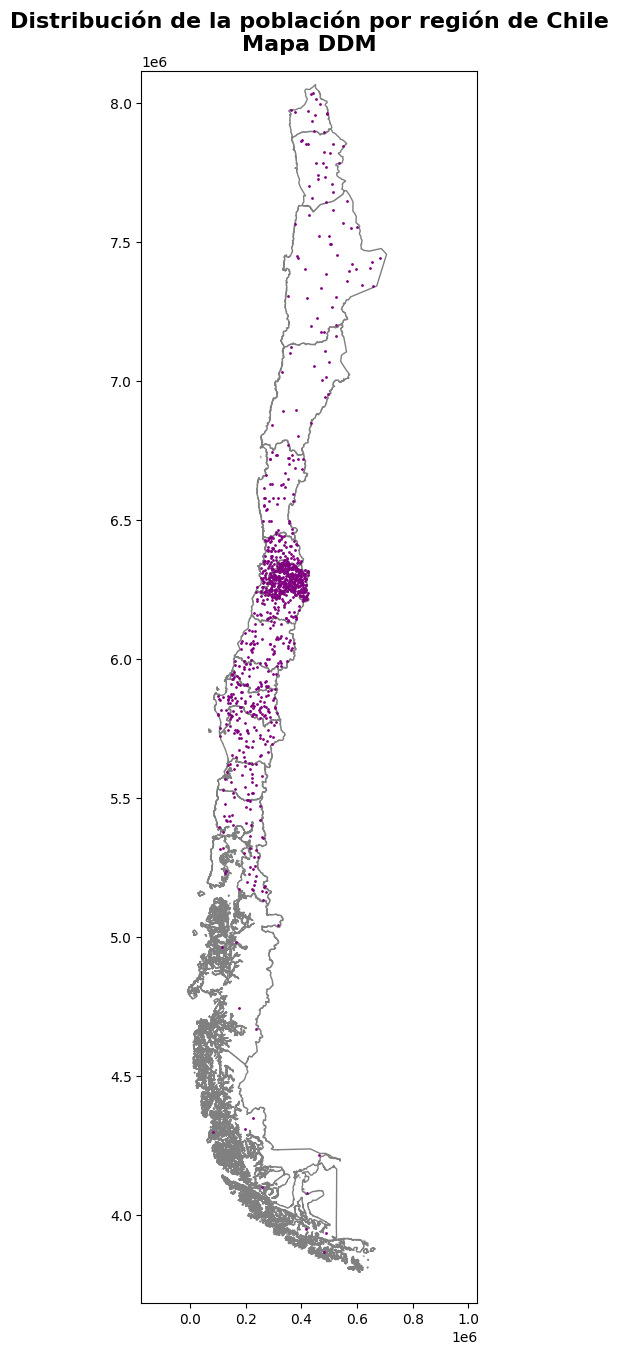

In [ ]:
# Representamos las regiones de Chile
base = MapaDatosChile_5361.plot(
    facecolor="white",
    edgecolor="grey"
)

# Representamos los puntos de población
Chile_dots.plot(
    markersize=1,
    color='purple',
    ax=base
)

# Título del mapa
base.set_title(
    'Distribución de la población por región de Chile\nMapa DDM',
    fontsize=16,
    pad=15,
    fontweight='bold'
)

# Encuadre manual en Chile
base.set_xlim(-175517, 1032781)
base.set_ylim(3683927, 8113636)

# Se aumenta el tamaño de la figura
base.figure.set_size_inches(8, 16)


## 7. PSM (Proportional Symbol Map)

En este apartado se representa la población mediante símbolos proporcionales. El tamaño de cada símbolo se determina de acuerdo con la cantidad de habitantes registrada en cada región.

**Preparación de los símbolos**

Se crea una copia del mapa proyectado y se ubica un punto representativo dentro de cada región. Luego se calcula el tamaño inicial de los símbolos según la población.



In [ ]:
# Se crea una copia para el PSM
Chile_centroids = MapaDatosChile_5361.copy()
# Se obtiene un punto representativo dentro de cada región
Chile_centroids['geometry'] = (MapaDatosChile_5361.representative_point())
# Se calcula el tamaño de los símbolos según la población
Chile_centroids['size'] = Chile_centroids[' 2024'].apply(lambda x: x**0.5/100)

**Identificación de valores atípicos**

Se revisan los posibles valores atípicos de la población mediante un boxplot.


array([7400741.0], dtype=object)

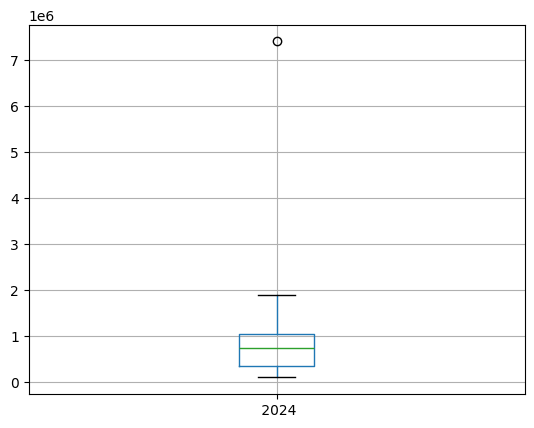

In [ ]:
# Se identifican posibles valores atípicos
boxplotInfo = Chile_centroids.boxplot(column=' 2024',return_type='dict')
# Se extraen los valores identificados como outliers
outliers = boxplotInfo['fliers'][0].get_ydata()
outliers

Se identifican las regiones que presentan los valores detectados como atípicos.

In [ ]:
# Se revisan las regiones con valores atípicos
Chile_centroids[Chile_centroids[' 2024'].isin(outliers)]

,GID_1,GID_0,COUNTRY,Region,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry,Variable,2024,size
13,CHL.14_1,CHL,Chile,SantiagoMetropolitan,RegiónMetropolitana|RégionMetr,NA,RegiónMetropolitana,MetropolianRegion,RM,CL.RM,NA,POINT (351138.59 6280670.481),Población total,7400741.0,27.204303


Se agrega una variable para distinguir las regiones con valores atípicos de las demás.

In [ ]:
# Se identifican los outliers con 1 y los demás con 0
Chile_centroids['population_outliers'] = (Chile_centroids[' 2024'].isin(outliers) * 1)
# Se verifica el GeoDataFrame actualizado
Chile_centroids

,GID_1,GID_0,COUNTRY,Region,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry,Variable,2024,size,population_outliers
0,CHL.2_1,CHL,Chile,Antofagasta,NA,NA,Región,Region,II,CL.AN,CL-AN,POINT (521598.549 7400327.81),Población total,635416.0,7.971299,0
1,CHL.3_1,CHL,Chile,Araucanía,Araucanie|LaAraucanía,NA,Región,Region,IX,CL.AR,NA,POINT (222409.949 5721875.909),Población total,1010423.0,10.051980,0
2,CHL.4_1,CHL,Chile,AricayParinacota,NA,NA,Región,Region,XV,CL.AP,CL-AP,POINT (425013.313 7969580.186),Población total,244569.0,4.945392,0
3,CHL.5_1,CHL,Chile,Atacama,NA,NA,Región,Region,III,CL.AT,CL-AT,POINT (407723.267 6967812.217),Población total,299180.0,5.469735,0
4,CHL.1_1,CHL,Chile,AyséndelGeneralIbañezdelCam,Aisén|Aysén|AiséndelGeneralCa,NA,Región,Region,XI,CL.AI,NA,POINT (233182.976 4850957.41),Población total,100745.0,3.174035,0
5,CHL.6_1,CHL,Chile,Bío-Bío,Bíobío,NA,Región,Region,VIII,CL.BI,NA,POINT (202636.522 5845324.274),Población total,1613059.0,12.700626,0
6,CHL.7_1,CHL,Chile,Coquimbo,NA,NA,Región,Region,IV,CL.CO,CL-CO,POINT (310268.79 6607103.639),Población total,832864.0,9.126138,0
7,CHL.8_1,CHL,Chile,LibertadorGeneralBernardoO'Hi,Libertador,NA,Región,Region,VI,CL.LI,NA,POINT (312792.695 6189542.39),Población total,987228.0,9.935935,0
8,CHL.9_1,CHL,Chile,LosLagos,OsLagos,NA,Región,Region,X,CL.LL,CL-LL,POINT (92832.701 5272299.419),Población total,890284.0,9.435486,0
9,CHL.10_1,CHL,Chile,LosRíos,NA,NA,Región,Region,XIV,CL.LR,NA,POINT (202590.062 5567306.652),Población total,398230.0,6.310547,0


Se separan las regiones con y sin valores atípicos para controlar su representación.

In [ ]:
# Se separan las regiones con valores atípicos
Chile_centroids_out = Chile_centroids[Chile_centroids.population_outliers == 1].copy()
# Se separan las regiones sin valores atípicos
Chile_centroids_no_out = Chile_centroids[Chile_centroids.population_outliers == 0].copy()

**Ajuste del tamaño de los símbolos**

Se calcula el tamaño final de los símbolos para ambos grupos.

In [ ]:
# Se calcula el tamaño final de los símbolos
Chile_centroids_out['size'] = ( Chile_centroids_out[' 2024'].apply(lambda x: x**0.6/50))
Chile_centroids_no_out['size'] = ( Chile_centroids_no_out[' 2024'].apply(lambda x: x**0.6/50))

**Representación del mapa**

Se representan las regiones sin valores atípicos y posteriormente aquellas que presentan valores atípicos.

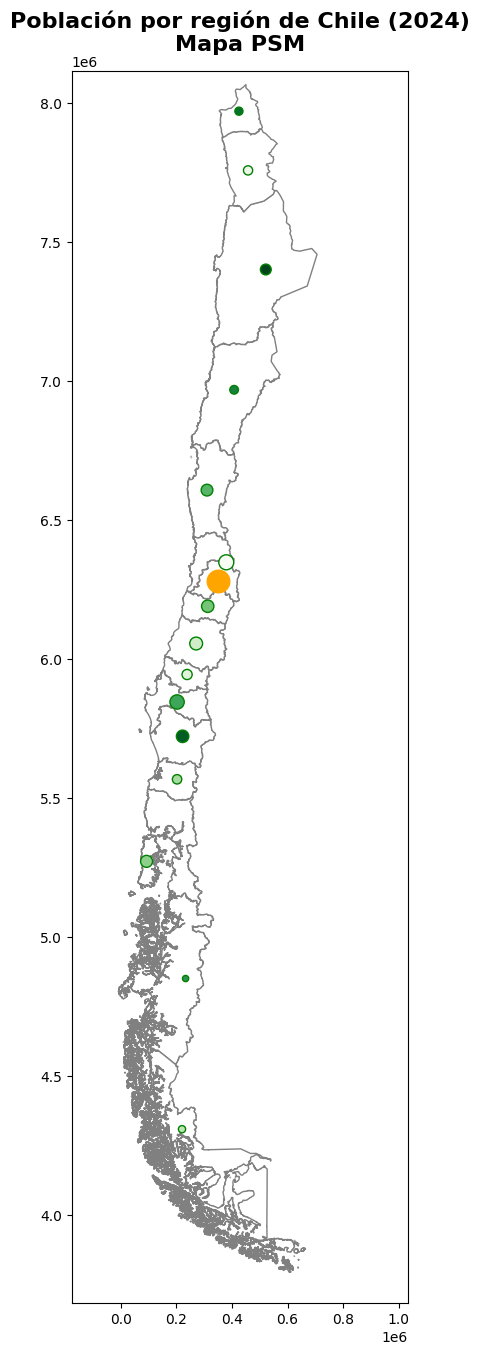

In [ ]:
# Se crea el mapa base
base = MapaDatosChile_5361.plot(
    facecolor='white',
    edgecolor='grey',
    figsize=(7,14)
)

# Se representan las regiones sin valores atípicos
Chile_centroids_no_out.plot(
    ax=base,
    markersize=Chile_centroids_no_out['size'],
    edgecolor='green',
    c=Chile_centroids_no_out['size'],
    cmap='Greens_r'
)

# Se representan las regiones con valores atípicos
Chile_centroids_out.plot(
    ax=base,
    markersize=Chile_centroids_out['size'],
    color='orange'
)

# Título del mapa
base.set_title(
    'Población por región de Chile (2024)\nMapa PSM',
    fontsize=16,
    fontweight='bold',
    pad=15
)

# Encuadre manual en Chile
base.set_xlim(-175517, 1032781)
base.set_ylim(3683927, 8113636)

# Se aumenta el tamaño de la figura
base.figure.set_size_inches(8, 16)

## 8. Preparación y Normalización de la Variable (Densidad Poblacional)

Para evaluar la distribución territorial sin el sesgo derivado del tamaño de las regiones, se estandariza el campo de conteo demográfico como `POBLACION`. Posteriormente, mediante una reproyección temporal a coordenadas métricas oficiales para Chile (EPSG:5361 - SIRGAS-Chile), se calcula la superficie en kilómetros cuadrados ($km^2$) y se normaliza la variable obteniendo la densidad demográfica ($hab/km^2$).

In [ ]:
# Limpieza de nombres de columnas y estandarización
MapaDatosChile.columns = MapaDatosChile.columns.str.strip()

if '2024' in MapaDatosChile.columns:
    MapaDatosChile.rename(columns={'2024': 'POBLACION'}, inplace=True)

MapaDatosChile['POBLACION'] = MapaDatosChile['POBLACION'].astype(float)

# Reproyección métrica temporal para medir área (EPSG:5361 - SIRGAS-Chile)
gdf_proyectado = MapaDatosChile.to_crs(epsg=5361)

# Cálculo de área en km² (m² / 1,000,000)
MapaDatosChile['AREA_KM2'] = gdf_proyectado.geometry.area / 10**6

# Normalización: Densidad demográfica
MapaDatosChile['DENSIDAD'] = MapaDatosChile['POBLACION'] / MapaDatosChile['AREA_KM2']

# Inspección estadística
print("--- Estadísticas Descriptivas ---")
print(MapaDatosChile[['POBLACION', 'AREA_KM2', 'DENSIDAD']].describe())
print("\nRegistros nulos en DENSIDAD:", MapaDatosChile['DENSIDAD'].isna().sum())
print("Total de regiones procesadas:", len(MapaDatosChile))

--- Estadísticas Descriptivas ---
          POBLACION       AREA_KM2    DENSIDAD
count  1.600000e+01      16.000000   16.000000
mean   1.155027e+06   47050.918690   58.004854
std    1.741920e+06   40764.752458  116.758062
min    1.007450e+05   13103.937948    0.944030
25%    3.521495e+05   16709.474551    8.198692
50%    7.341400e+05   31079.842829   21.175268
75%    1.038569e+06   55215.273319   44.414875
max    7.400741e+06  133016.397650  480.824388

Registros nulos en DENSIDAD: 0
Total de regiones procesadas: 16


## 9. Discretización de la Densidad Demográfica

La variable de densidad presenta una notable asimetría debido a la concentración urbana en la zona central. Para particionar los datos de forma analítica se utiliza el algoritmo de clasificación **Fisher-Jenks (Natural Breaks)** en 5 intervalos, minimizando la varianza interna de cada grupo y resaltando las discontinuidades espaciales del territorio.

In [ ]:
!pip install mapclassify -q

import mapclassify

# Discretización en 5 intervalos mediante Fisher-Jenks sobre la variable normalizada
k_intervalos = 5
clasificador_jenks = mapclassify.NaturalBreaks(MapaDatosChile['DENSIDAD'], k=k_intervalos)

print("Intervalos calculados para DENSIDAD (Fisher-Jenks):")
print(clasificador_jenks)

Intervalos calculados para DENSIDAD (Fisher-Jenks):
NaturalBreaks

    Interval       Count
------------------------
[  0.94,  14.53] |     6
( 14.53,  39.09] |     6
( 39.09,  67.14] |     2
( 67.14, 116.15] |     1
(116.15, 480.82] |     1


## 10. Representación Cartográfica: Mapa Coroplético Normalizado

Se elabora el mapa coroplético utilizando la escala de color secuencial `viridis` aplicada a la densidad regional discretizada. Para evitar la deformación visual causada por los territorios insulares alejados, se acota la extensión geográfica al territorio continental chileno, situando la leyenda en el espacio marítimo para evitar solapamientos con la geometría continental.


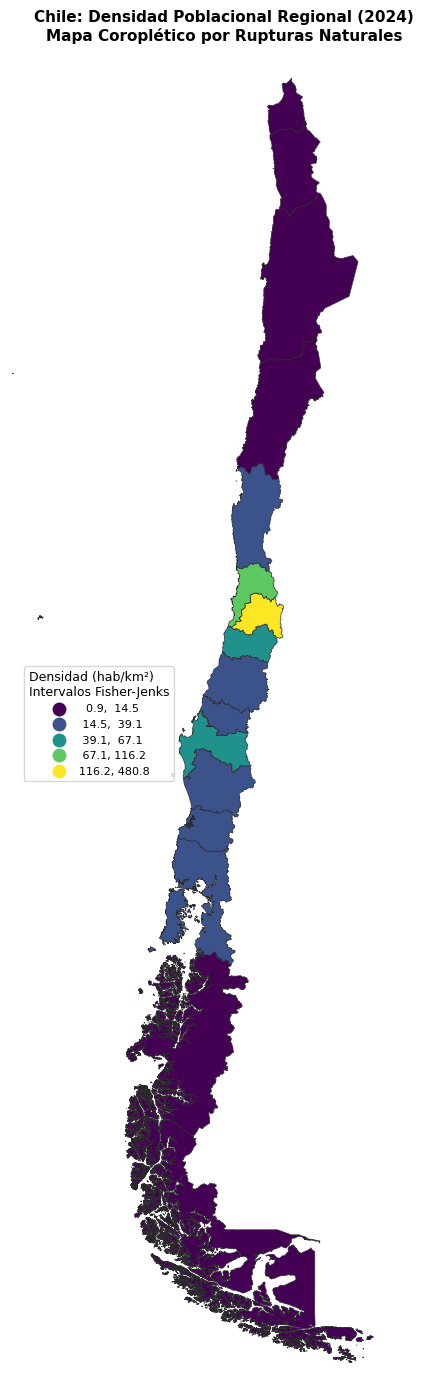

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 14))

# Mapa Coroplético de Densidad
MapaDatosChile.plot(
    column='DENSIDAD',
    scheme='NaturalBreaks',
    k=k_intervalos,
    cmap='viridis',
    edgecolor='#2b2b2b',
    linewidth=0.45,
    legend=True,
    legend_kwds={
        'loc': 'lower left',
        'bbox_to_anchor': (0.02, 0.45),
        'title': 'Densidad (hab/km²)\nIntervalos Fisher-Jenks',
        'title_fontsize': 9,
        'fontsize': 8,
        'frameon': True,
        'facecolor': 'white',
        'edgecolor': '#cccccc',
        'fmt': '{:,.1f}'
    },
    ax=ax
)

# Encuadre en Chile continental
ax.set_xlim(-80, -64)
ax.set_ylim(-56.5, -17)

# Título formal y supresión de ejes
ax.set_title(
    'Chile: Densidad Poblacional Regional (2024)\nMapa Coroplético por Rupturas Naturales',
    fontsize=11,
    fontweight='bold',
    pad=15
)
ax.set_axis_off()

plt.tight_layout()
plt.show()

## 11. Verificación de integridad de datos y geometrías

Se realiza la comprobación final de las variables requeridas en la estructura tabular y la consistencia de los tipos geométricos en el GeoDataFrame consolidado.


In [ ]:
# Verificación de estructura final
columnas_requeridas = ['Region', 'POBLACION', 'AREA_KM2', 'DENSIDAD']
print("Estructura final del GeoDataFrame (16 regiones):")
print(MapaDatosChile[columnas_requeridas].to_string())

print("\nTipo geométrico predominante:")
print(MapaDatosChile.geometry.geom_type.value_counts())

Estructura final del GeoDataFrame (16 regiones):
                           Region  POBLACION       AREA_KM2    DENSIDAD
0                     Antofagasta   635416.0  126031.097119    5.041740
1                       Araucanía  1010423.0   31837.268038   31.737114
2                AricayParinacota   244569.0   16828.915605   14.532665
3                         Atacama   299180.0   75664.607155    3.954028
4     AyséndelGeneralIbañezdelCam   100745.0  106717.957008    0.944030
5                         Bío-Bío  1613059.0   24026.674885   67.136173
6                        Coquimbo   832864.0   40579.979806   20.524012
7   LibertadorGeneralBernardoO'Hi   987228.0   16351.151388   60.376666
8                        LosLagos   890284.0   48398.828707   18.394743
9                         LosRíos   398230.0   18245.232447   21.826524
10    MagallanesyAntárticaChilena   166537.0  133016.397650    1.252004
11                          Maule  1123008.0   30322.417619   37.035569
12             

## 12. Guardado de los resultados

En esta última parte se almacenan los resultados en un mismo GeoPackage. Cada representación se guarda como una capa independiente para facilitar su posterior utilización.

In [ ]:
# Se guardan los resultados en un mismo GeoPackage
MapaDatosChile.to_file('chile_poblacion.gpkg',driver='GPKG',layer='poblacion_regional')
Chile_dots.to_file('chile_poblacion.gpkg',driver='GPKG',layer='poblacion_dots')
Chile_centroids.to_file('chile_poblacion.gpkg',driver='GPKG',layer='poblacion_psm')
Chile_centroids_out.to_file('chile_poblacion.gpkg',driver='GPKG',layer='outlier_poblacion_psm')
Chile_centroids_no_out.to_file('chile_poblacion.gpkg',driver='GPKG',layer='no_outlier_poblacion_psm')